In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [13]:
df = pd.read_csv("thyroid_dataset.csv")

In [14]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [16]:
from sklearn.ensemble import IsolationForest

In [18]:
iso = IsolationForest(
    n_estimators = 200,
    contamination = "auto",
    random_state = 42
)
labels = iso.fit_predict(X_scaled)

In [19]:
#visualize using pca
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

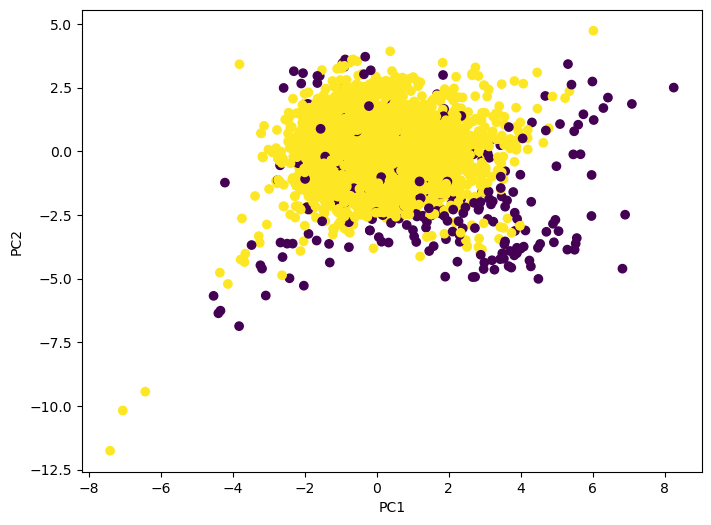

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c = labels
)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [25]:
#no of outlier
import numpy as np
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels==1)
print("outliers = ",n_outliers)
print("normal = ",n_normal)

outliers =  270
normal =  6646
